# FABN Bond Portfolio Optimizer — Gurobi  *(v2 — Lending Facility + Cash Shielding + Bond Liquidation)*

**Goal:** Maximize the Net Economic Value (NEV) of a Funding Agreement-Backed Note (FABN)
strategy by optimally allocating capital $h_i$ across a fixed-income universe.

---

## Objective Function

$$
\max_{h} \left[
\underbrace{\sum_{i \in \mathcal{S}} \bigl(Spread_i + \beta\, Signal_i\bigr)\, h_i}_{\text{Relative Value}}
\;-\;
\gamma \underbrace{\bigl(C_1(h) + C_3(h)\bigr)}_{\text{Capital cost}}
\;-\;
\underbrace{\sum_{i} \tau_i\, |h_i - h_i^{curr}|}_{\text{Transaction cost}}
\right]
$$

CF shortfall is **not** penalised in the objective — it is controlled entirely by the lending-facility hard cap constraint (see Linearization below).

| Component | Formula | Notes |
|---|---|---|
| $Spread_i$ | $y_i - r^{FABN}$ | Yield minus funding rate |
| $C_1(h)$ | $\sum_i \theta_i h_i$ | C-1 credit risk capital |
| $C_3(h)$ | $\alpha \left\lvert \sum_i D_i h_i - D^{FABN} H \right\rvert$ | C-3 ALM mismatch; $H = \sum_i h_i$ fixed by budget |

---

## Linearization & CF Shortfall Control

All nonlinear terms are reformulated using auxiliary variables and linear constraints, resulting in a standard linear program (LP) solvable by Gurobi.

- Absolute Value: |x| → d⁺ + d⁻
- Max: max(0, x) → two non-negative variables whose difference equals the argument

| Nonlinear term | Auxiliary vars | LP reformulation |
|---|---|---|
| $C_3$: absolute value of duration gap | $d^+, d^- \geq 0$ | $d^+ - d^- = \sum D_i h_i - D^{FABN}H$; $\;C_3 = \alpha(d^+ + d^-)$ |
| Transaction costs: $\|h_i - h_i^{curr}\|$ | $tc^+_i,\, tc^-_i \geq 0$ | $tc^+_i - tc^-_i = h_i - h_i^{curr}$; cost $= \tau_i(tc^+_i + tc^-_i)$ |
| CF net shortfall with lending facility: $\max\!\bigl(0,\;CF_q^L - CF_q^A - B_{q-1}(1+r_{\text{lend}}\delta)\bigr)$ | $B_q,\; s_q^{net} \geq 0$ | $B_q - s_q^{net} = (1+r_{\text{lend}}\,\delta)\,B_{q-1} + CF_q^A - CF_q^L$; surplus accumulates in $B_q$, residual shortfall captured in $s_q^{net}$ |
| Duration constraint: $\|D_{avg} - D^{FABN}\| \leq \varepsilon_D$ | same $d^+, d^-$ | $d^+ \leq \varepsilon_D H$; $\;d^- \leq \varepsilon_D H$ |

**CF shortfall hard cap (replaces the v1 soft penalty):**
$$\sum_q \text{df}_q \cdot s_q^{net} \;\leq\; \phi \cdot PV(\text{FABN liability}) \qquad (\phi = 1\%\ \text{default})$$

---

## Pipeline Overview
0. **Imports** — libraries
1. **Data & Parameters** — load inputs; build `aug_bond_cf` (bond liquidation proceeds credited at FABN maturity quarter)
2. **Gurobi Model** — formulate and solve the LP
3. **Results** — extract allocations and NEV breakdown
4. **Analytics** — tables and charts

---

## Quick Start — What to Run and When

| Section | Always run? | Uncomment when… |
|---|:---:|---|
| **Date Selection** | Yes | — change `optimization_date` to the desired date |
| **0 — Imports** | Yes | — |
| **1A — Unpack pipeline** | Yes | — |
| **1B — Signal override** | No | You want market signals to influence allocation |
| **1B — Transaction cost override** | No | You want to penalize portfolio turnover |
| **1B — Solvency override** | No | You have confirmed capital figures from Athene |
| **1B — Lending facility / PV cap override** | No | You want to change `r_lend` or `phi_sf` from their defaults |
| **1C — Accrual + Valuation score** | No | You want coupon-based return instead of OAS spread proxy |
| **1C — After-tax score** | No | 1C accrual block is active and you want after-tax returns |
| **2 — Core model** | Yes | — |
| **2E — Issuer concentration** | No | You want to cap single-issuer exposure |
| **2E — Credit quality limit** | No | You want to cap exposure to below-IG bonds |
| **2E — Liquidity requirement** | No | You want to enforce minimum liquid holdings |
| **2E — Convexity** | No | `pipeline["convexity"]` has been added to the pipeline |
| **3 — Results** | Yes | — |
| **4 — Analytics** | Yes | — |

**Run order:** `Date Selection → 0 → 1A → (1B) → (1C) → 2 → 3 → 4`  
To re-run for a **different date**: change `optimization_date` in the **Date Selection** cell and re-run all cells top-to-bottom.  
Parentheses = optional; run those cells only when their block is uncommented.

---
## Changes vs `FABN_Optimizer_Gurobi_Clean` (v1)

### 1 — Lending Facility + Cash Shielding *(Section 2B, 2D)*
**What changed:** The simple per-quarter shortfall variable `s[q]` is replaced by two new variables:
- `B[q]` — lending facility balance (accumulated surplus, earns `r_lend` per quarter).
- `s_net[q]` — net shortfall **after** drawing from the facility.

**New constraint per quarter:**
$$B_q - s_q^{net} = (1 + r_{\text{lend}}\,\delta)\,B_{q-1} + CF_q^A - CF_q^L$$

When assets generate more than the FABN needs, the surplus goes into `B[q]`. When assets fall short, the facility is drawn down first — only whatever remains uncovered becomes `s_net[q]`. This connects quarters that were previously treated independently.

**Tunable parameters (override in Section 1B):**
| Parameter | Default | Meaning |
|---|---|---|
| `r_lend` | `r_FABN` (3.205%) | Annualised rate earned on facility balance |
| `phi_sf` | `0.01` (1%) | Max PV(shortfall) / PV(liability) — hard cap |
| `dt_q` | `0.25` | Quarter length in years |

---

### 2 — PV Shortfall Hard Cap *(Section 2D)*
**What changed:** Added a binding constraint on total shortfall exposure in present-value terms:
$$\sum_q \text{df}_q \cdot s_q^{net} \;\leq\; \phi \cdot PV(\text{FABN liability})$$

In v1, shortfall was only penalised *softly* via `lambda_w` in the objective — the optimizer could accept large shortfalls if they were cheap enough. This constraint sets a hard ceiling so that total shortfall (discounted) never exceeds 1% of the liability's economic value, regardless of the penalty weight.

---

### 3 — Bond Liquidation at FABN Maturity *(Section 2D)*
**What changed:** Bonds that mature after the FABN (2027-09-06) are no longer ignored or excluded. Instead, at the FABN maturity quarter (`fabn_last_q`), their sale proceeds are credited as additional asset cash flow:
$$aug\_bond\_cf_{fabn\_last\_q,\,i} \mathrel{+}= \sum_{q > fabn\_last\_q} CF_{q,i} \cdot (1 + r_{FABN})^{-(q - fabn\_last\_q)\,\delta}$$
Cash flows in all subsequent quarters are set to zero (bonds are sold). This keeps the full bond universe eligible while correctly accounting for the economic value recovered at liquidation.

---

### 4 — Fig 2 updated *(Section 4D)*
**What changed:** The quarterly CF chart now:
- Shows only the 6 quarters where the FABN actually pays (not all 33 quarters).
- Stacks the asset bar: **blue** = direct asset CF, **teal** = lending facility carry-in available that quarter. When blue + teal ≥ red, that payment is fully covered.

---
## Section 0 — Imports

In [44]:
# =============================================================================
# DATE SELECTION  —  change this date, then re-run all cells top-to-bottom
# =============================================================================
# Set to any business day for which spread data exists in BigQuery.
# Valid range: 2022-09-07 (day after FABN issue) through 2027-09-05 (day before maturity).
#
# Run order after changing the date:
#   this cell  →  Section 0  →  1A  →  (1B)  →  (1C)  →  2  →  3  →  4

import pandas as pd   # imported here so the date is available before %run

optimization_date = pd.Timestamp("2025-01-15")   # ← CHANGE THIS DATE

# ── Validation ────────────────────────────────────────────────────────────
_FABN_ISSUE    = pd.Timestamp("2022-09-06")
_FABN_MATURITY = pd.Timestamp("2027-09-06")

assert optimization_date <= pd.Timestamp.today(), (
    f"Date {optimization_date.date()} is in the future — no market data available."
)
assert optimization_date > _FABN_ISSUE, (
    f"Date {optimization_date.date()} must be after FABN issue ({_FABN_ISSUE.date()})."
)
assert optimization_date < _FABN_MATURITY, (
    f"Date {optimization_date.date()} is on or after FABN maturity ({_FABN_MATURITY.date()}). "
    f"No future FABN payments remain — D_FABN would be undefined."
)

print(f"Optimization date selected : {optimization_date.date()}")
print("Re-run all sections below (0 → 1A → 2 → 3 → 4) to update the portfolio optimization.")

Optimization date selected : 2025-01-15
Re-run all sections below (0 → 1A → 2 → 3 → 4) to update the portfolio optimization.


In [45]:
# Runs the data pipeline — loads bond universe, FABN schedule, cash flows,
# durations, C-1 charges, spreads, and all model parameters into `pipeline`.
%run FABN_Data_Pipeline.ipynb

import gurobipy as gp
from gurobipy import GRB
import matplotlib.pyplot as plt
# numpy and pandas are already imported by the pipeline

Connected: insurance-backed-securities
Optimization date  : 2025-01-15
FABN issue/maturity: 2022-09-06 → 2027-09-06
Budget H           : $500,000,000
r_FABN             : 3.205%
Universe size N = 303 bonds
Fechas disponibles en Agg_Spread_Long (≤ 2025-01-15, últimas 30):
2025-01-15
2025-01-14
2025-01-13
2025-01-10
2025-01-09
2025-01-08
2025-01-07
2025-01-06
2025-01-03
2025-01-02
2024-12-31
2024-12-30
2024-12-27
2024-12-26
2024-12-24
2024-12-23
2024-12-20
2024-12-19
2024-12-18
2024-12-17
2024-12-16
2024-12-13
2024-12-12
2024-12-11
2024-12-10
2024-12-09
2024-12-06
2024-12-05
2024-12-04
2024-12-03

Spread coverage : 301/303 bonds  (2 missing)
Spread range    : -1.6 – 153.7 bps
Fechas únicas usadas    : 1  (2025-01-15 – 2025-01-15)
Staleness (días atrás)  : min 0  /  media 0  /  max 0
Cashflow rows loaded : 2,517
Date range           : 2025-01-16 → 2033-02-15
bond_cf shape : (850, 303)  (T=850 payment dates × N=303 bonds)
qtr_bond_cf shape : (33, 303)  (Q=33 quarters × N=303 bonds)
Quarter

,Metric,Value,Notes
0,Universe size (N),303,
1,Payment dates (T),850,
2,Quarterly periods (Q),33,
3,Spread mean (bps),59.4,
4,Duration mean (yrs),2.97,
5,C1 charge mean (%),0.911,
6,FABN D target (yrs),2.489641,
7,Budget H ($M),500.0,



pipeline dict ready.


---
## Section 1 — Data & Parameters

In [46]:
# =============================================================================
# 1A. UNPACK PIPELINE  —  always run
# =============================================================================

N            = pipeline["N"]
T            = pipeline["T"]
Q            = pipeline["Q"]
CUSIPS       = pipeline["CUSIPS"]

spread       = pipeline["spread"]       # Spread_i = y_i - r_FABN  (decimal)
durs         = pipeline["durs"]         # D_i : modified duration (years)
theta        = pipeline["theta"]        # theta_i : C-1 RBC charge factor
h_curr       = pipeline["h_curr"]       # h_curr_i : current allocation ($)

bond_cf      = pipeline["bond_cf"]      # asset cash flows  (T x N)
qtr_bond_cf  = pipeline["qtr_bond_cf"]  # quarterly view    (Q x N)
qtr_fabn_cf  = pipeline["qtr_fabn_cf"]  # FABN liability cash flows (Q,)
qtr_idx      = pipeline["qtr_idx"]

H            = pipeline["H"]            # total budget ($)
r_FABN       = pipeline["r_FABN"]       # funding rate r^FABN (annual)
D_FABN       = pipeline["D_FABN"]       # liability modified duration (yrs)

C_curr       = pipeline["C_curr"]       # current regulatory capital ($)
C_min        = pipeline["C_min"]        # RBC minimum capital floor ($)
RBC_bar      = pipeline["RBC_bar"]      # minimum solvency ratio
dt           = pipeline["dt"]           # time scaling factor (annualized)

gamma_w      = pipeline["gamma_w"]      # gamma  : weight on capital cost (C1 + C3)
beta_w       = pipeline["beta_w"]       # beta   : weight on market signal (0 by default)
alpha_w      = pipeline["alpha_w"]      # alpha  : C3 scaling for duration mismatch
lambda_w     = pipeline["lambda_w"]     # lambda : weight on CF shortfall penalty
eps_D        = pipeline["eps_D"]        # epsilon_D : duration band tolerance (yrs)

signal       = pipeline["signal"]       # Signal_i  (N,) — zeros by default
tau          = pipeline["tau"]          # tau_i     (N,) — zeros by default
score        = pipeline["score"]        # score_i = spread_i + beta_w * signal_i

print(f"Pipeline loaded: N={N}, T={T}, Q={Q}")
print(f"Optimization date: {optimization_date.date()}")

Pipeline loaded: N=303, T=850, Q=33
Optimization date: 2025-01-15


In [ ]:
# =============================================================================
# 1B. INPUT OVERRIDES
# =============================================================================
# Run this cell only when you uncomment at least one block below.
# Each block is independent — you can activate any combination.
# Re-run this cell, then re-run Section 2 to apply changes.

# -----------------------------------------------------------------------------
# UNCOMMENT IF: you want market signals to influence which bonds are selected.
# -----------------------------------------------------------------------------
# fixed_df   = pipeline["fixed"]
# sector_map = fixed_df.set_index("CUSIP")["sector"]
# spread_s   = pd.Series(spread, index=CUSIPS)
# signal     = spread_s.groupby(sector_map).transform(
#                  lambda x: (x - x.mean()) / (x.std() + 1e-8)
#              ).values
# beta_w     = 0.10
# score      = spread + beta_w * signal

# -----------------------------------------------------------------------------
# UNCOMMENT IF: you want to penalize portfolio turnover (transaction costs).
# -----------------------------------------------------------------------------
# tau = np.where(theta <= 0.02, 0.0005, 0.0020)

# -----------------------------------------------------------------------------
# UNCOMMENT IF: you have confirmed regulatory capital figures from Athene.
# -----------------------------------------------------------------------------
# C_curr  = 50_000_000.0
# C_min   =  1_000_000.0
# RBC_bar = 1.5

# -----------------------------------------------------------------------------
# UNCOMMENT IF: you want to override the surplus savings rate or borrowing rate.
# -----------------------------------------------------------------------------
# Both parameters are set at the top of Section 2 (with their defaults shown).
# Uncomment and run this cell BEFORE running Section 2 to override them.
#
# r_save   = 0.02   # annualised rate earned on facility surplus   (default 2 %)
# r_borrow = 0.05   # annualised rate paid on CF shortfalls        (default 5 %)
# phi_sf   = 0.005  # PV shortfall cap — inactive (constraint commented out in Section 2)


---
### Section 1C — Score Override *(run before Section 2 if activating)*

In [48]:
# =============================================================================
# 1C. SCORE / RETURN OVERRIDES
# =============================================================================
# Run this cell only when you uncomment a block below.
# MUST be run BEFORE Section 2 — these blocks replace the `score` variable
# that the optimizer uses in its objective function.
# Re-run Section 2 after changing score.

# -----------------------------------------------------------------------------
# UNCOMMENT IF: you want coupon-based return instead of the OAS spread proxy.
# -----------------------------------------------------------------------------
# Paper ref: § "Accounting Principles" — Return_i = Accrual_i + Valuation_i
#
# accrual[i]   = annual coupon rate of bond i (decimal, from pipeline["fixed"])
# valuation[i] = expected price change — set to 0 until a rate forecast is available
# score[i]     = accrual[i] + valuation[i] - r_FABN
#
# fixed_df   = pipeline["fixed"]
# coupon_map = fixed_df.set_index("CUSIP")["coupon"] / 100.0
# accrual    = np.array([coupon_map[c] for c in CUSIPS])
# valuation  = np.zeros(N)
# score      = accrual + valuation - r_FABN

# -----------------------------------------------------------------------------
# UNCOMMENT IF: the accrual block above is active and you want after-tax returns.
# -----------------------------------------------------------------------------
# Paper ref: § "Tax Considerations"
# Return_i^AT = (1 - pi_c) * Accrual_i + (1 - pi_g) * Valuation_i
# Requires the accrual block above to be uncommented first.
#
# pi_c  = 0.21    # ordinary income tax rate
# pi_g  = 0.15    # capital gains tax rate
# score = (1 - pi_c) * accrual + (1 - pi_g) * valuation - r_FABN

---
## Section 2 — Gurobi Optimization Model

In [ ]:
# =============================================================================
# 2. GUROBI OPTIMIZATION MODEL  —  always run
# =============================================================================

model = gp.Model("FABN_NEV_Optimizer")
model.Params.LogToConsole = 1   # set to 0 to suppress solver output

# ── Rates and time step  (override in Section 1B before running) ────────────
r_save   = 0.02    # annualised rate earned on surplus accumulated in the facility
r_borrow = 0.05    # annualised rate paid when borrowing to cover CF shortfalls
phi_sf   = 0.01    # PV shortfall cap  (1% of PV liability)
dt_q     = 0.25    # quarter length in years

# ---------------------------------------------------------------------------
# 2A. DECISION VARIABLES
# ---------------------------------------------------------------------------

h = model.addVars(N, lb=0.0, name="h")

# ---------------------------------------------------------------------------
# 2B. AUXILIARY VARIABLES
# ---------------------------------------------------------------------------

d_pos = model.addVar(lb=0.0, name="d_pos")
d_neg = model.addVar(lb=0.0, name="d_neg")

tc_plus  = model.addVars(N, lb=0.0, name="tc_plus")
tc_minus = model.addVars(N, lb=0.0, name="tc_minus")

B     = model.addVars(Q, lb=0.0, name="B")
s_net = model.addVars(Q, lb=0.0, name="s_net")

# ---------------------------------------------------------------------------
# 2C. OBJECTIVE FUNCTION
# ---------------------------------------------------------------------------

spread_income      = gp.quicksum(score[i] * h[i] for i in range(N))
C1                 = gp.quicksum(theta[i] * h[i] for i in range(N))
C3                 = alpha_w * (d_pos + d_neg)
capital_cost       = gamma_w * (C1 + C3)
txn_cost           = gp.quicksum(tau[i] * (tc_plus[i] + tc_minus[i]) for i in range(N))

# Interest earned on surplus each quarter: B[q] carries into quarter q+1
# and earns r_save × dt_q.  Summed over q = 0..Q-2 (B[Q-1] has no next quarter).
savings_income_obj = gp.quicksum(r_save   * dt_q * B[q]     for q in range(Q - 1))
borrowing_cost_obj = gp.quicksum(r_borrow * dt_q * s_net[q] for q in range(Q))

NEV = spread_income + savings_income_obj - capital_cost - txn_cost - borrowing_cost_obj
model.setObjective(NEV, GRB.MAXIMIZE)

# ---------------------------------------------------------------------------
# 2D. CORE CONSTRAINTS  —  always active
# ---------------------------------------------------------------------------

# Budget: Sum h_i = H
model.addConstr(
    gp.quicksum(h[i] for i in range(N)) == H,
    name="budget"
)

# Solvency / RBC: (C_curr + Sum Spread_i*h_i*dt) / C_min >= RBC_bar
rbc_rhs = (RBC_bar * C_min - C_curr) / dt
model.addConstr(
    gp.quicksum(spread[i] * h[i] for i in range(N)) >= rbc_rhs,
    name="solvency"
)

# Duration alignment: |D_avg - D_FABN| <= eps_D
model.addConstr(
    gp.quicksum(durs[i] * h[i] for i in range(N)) - D_FABN * H == d_pos - d_neg,
    name="dur_gap_decomp"
)
model.addConstr(d_pos <= eps_D * H, name="dur_upper")
model.addConstr(d_neg <= eps_D * H, name="dur_lower")

# Transaction cost decomposition
for i in range(N):
    model.addConstr(
        h[i] - h_curr[i] == tc_plus[i] - tc_minus[i],
        name=f"tc_decomp_{i}"
    )

# ── Lending Facility + Cash Shielding ──────────────────────────────────────

t_quarters = [dt_q * (q + 1) for q in range(Q)]
df_q       = [(1.0 + r_FABN) ** (-t) for t in t_quarters]

# ── Bond liquidation at FABN maturity ──────────────────────────────────────
fabn_last_q = max(q for q in range(Q) if float(qtr_fabn_cf[q]) > 0)

aug_bond_cf = qtr_bond_cf.copy().astype(float)
for _i in range(N):
    for _q in range(fabn_last_q + 1, Q):
        _dt = (_q - fabn_last_q) * dt_q
        aug_bond_cf[fabn_last_q, _i] += qtr_bond_cf[_q, _i] * (1.0 + r_FABN) ** (-_dt)
        aug_bond_cf[_q, _i] = 0.0

_n_tail = int(np.any(qtr_bond_cf[fabn_last_q + 1:] > 1e-6, axis=0).sum())
print(f"Bond liquidation: {_n_tail}/{N} bonds have post-{qtr_idx[fabn_last_q]} CF → "
      f"sale proceeds discounted to {qtr_idx[fabn_last_q]}")

# Lending facility balance dynamics
# Surplus grows at r_save each quarter; shortfalls s_net[q] are penalised
# in the objective at r_borrow (see Section 2C above).
for q in range(Q):
    CF_A_q = gp.quicksum(aug_bond_cf[q, i] * h[i] for i in range(N))
    CF_L_q = float(qtr_fabn_cf[q])
    if q == 0:
        model.addConstr(B[q] - s_net[q] == CF_A_q - CF_L_q,
                        name=f"facility_balance_{q}")
    else:
        model.addConstr(B[q] - s_net[q] == (1.0 + r_save * dt_q) * B[q - 1] + CF_A_q - CF_L_q,
                        name=f"facility_balance_{q}")

# PV shortfall hard cap — keeps total discounted shortfall <= phi_sf * PV(liability).
# Required to bound the LP when savings_income_obj is in the objective: without this
# cap, the solver can inflate s_net[q] (which cascades into B[q+1], B[q+2], …) to
# earn unbounded savings income at a net gain over the borrowing penalty.
PV_liability = float(sum(float(qtr_fabn_cf[q]) * df_q[q] for q in range(Q)))
model.addConstr(
    gp.quicksum(df_q[q] * s_net[q] for q in range(Q)) <= phi_sf * PV_liability,
    name="pv_shortfall_limit"
)
print(f"r_save   (surplus earns)   :  {r_save   * 100:.2f}%  per year")
print(f"r_borrow (shortfall costs) :  {r_borrow * 100:.2f}%  per year")
print(f"phi_sf   (PV shortfall cap):  {phi_sf   * 100:.2f}%  of PV liability")
print(f"PV(FABN liability)         = ${PV_liability:>14,.2f}")

# ---------------------------------------------------------------------------
# 2E. EXTENSION CONSTRAINTS  —  uncomment individually to activate
# ---------------------------------------------------------------------------

delta = 0.05   # max 5% of total budget per issuer
issuer_groups = {}
for idx, cusip in enumerate(CUSIPS):
    issuer_groups.setdefault(cusip[:6], []).append(idx)
for issuer, bond_indices in issuer_groups.items():
    model.addConstr(
        gp.quicksum(h[i] for i in bond_indices) <= delta * H,
        name=f"concentration_{issuer}"
    )

# ---------------------------------------------------------------------------
# 2F. SOLVE
# ---------------------------------------------------------------------------

model.optimize()

---
## Section 3 — Results

In [ ]:
# =============================================================================
# 3. RESULTS EXTRACTION  —  always run
# =============================================================================

if model.Status == GRB.OPTIMAL:

    h_opt = np.array([h[i].X for i in range(N)])

    nev_val            = model.ObjVal
    spread_income_val  = float(sum(score[i] * h_opt[i] for i in range(N)))
    C1_val             = float(sum(theta[i] * h_opt[i] for i in range(N)))
    C3_val             = alpha_w * (d_pos.X + d_neg.X)
    capital_cost_val   = gamma_w * (C1_val + C3_val)
    txn_cost_val       = float(sum(tau[i] * (tc_plus[i].X + tc_minus[i].X) for i in range(N)))

    # Extract facility solution values once — reused in Sections 3B and 4
    B_vals     = [B[q].X     for q in range(Q)]
    s_net_vals = [s_net[q].X for q in range(Q)]

    savings_income_val = r_save   * dt_q * float(sum(B_vals[q]     for q in range(Q - 1)))
    borrowing_cost_val = r_borrow * dt_q * float(sum(s_net_vals[q] for q in range(Q)))

    D_avg   = float(sum(durs[i] * h_opt[i] for i in range(N))) / H
    RBC_val = (C_curr + float(sum(spread[i] * h_opt[i] for i in range(N))) * dt) / C_min

    print(f"{'='*55}")
    print(f"  OPTIMAL NEV              : ${nev_val:>12,.2f}")
    print(f"  (1) Spread income        : ${spread_income_val:>12,.2f}")
    print(f"  (2) Savings income       : ${savings_income_val:>12,.2f}")
    print(f"  (4) Capital cost (C1+C3) : ${capital_cost_val:>12,.2f}")
    print(f"      - C1 (credit risk)   : ${C1_val:>12,.2f}")
    print(f"      - C3 (duration ALM)  : ${C3_val:>12,.2f}")
    print(f"  (5) Transaction costs    : ${txn_cost_val:>12,.2f}")
    print(f"  (6) Borrowing cost       : ${borrowing_cost_val:>12,.2f}")
    print(f"{'='*55}")
    print(f"  Portfolio D_avg          :  {D_avg:.4f} yrs  (target {D_FABN} +/- {eps_D})")
    print(f"  RBC ratio                :  {RBC_val:.2f}x  (min {RBC_bar:.1f}x)")
    print(f"{'='*55}")

    # Constraint status table
    constraints_df = pd.DataFrame({
        "Constraint"  : [
            "Budget  (Sum h_i = H)",
            "Solvency  (RBC >= RBC_bar)",
            "Duration  (|D_avg - D_FABN| <= eps_D)",
        ],
        "Value"       : [h_opt.sum(), RBC_val, abs(D_avg - D_FABN)],
        "Bound"       : [H, RBC_bar, eps_D],
        "Pass / Fail" : [
            "PASS" if abs(h_opt.sum() - H) < 1.0  else "FAIL",
            "PASS" if RBC_val >= RBC_bar            else "FAIL",
            "PASS" if abs(D_avg - D_FABN) <= eps_D else "FAIL",
        ],
    })
    display(constraints_df)

    CF_A_vals = [sum(aug_bond_cf[q, i] * h_opt[i] for i in range(N)) for q in range(Q)]
    cf_df = pd.DataFrame({
        "Period"              : qtr_idx,
        "FABN CF ($)"         : qtr_fabn_cf,
        "Asset CF ($)"        : CF_A_vals,
        "Surplus ($)"         : [a - l for a, l in zip(CF_A_vals, qtr_fabn_cf)],
        "Shortfall net ($)"   : s_net_vals,
        "Facility bal ($)"    : B_vals,
    })
    display(cf_df)

elif model.Status == GRB.INFEASIBLE:
    print("Model is INFEASIBLE. Computing IIS to identify conflicting constraints...")
    model.computeIIS()
    model.write("infeasible.ilp")
    print("IIS written to infeasible.ilp")

else:
    print(f"Solver status code: {model.Status} — no optimal solution found.")

In [ ]:
# =============================================================================
# 3B. EXPANDED QUARTERLY CASH FLOW TABLE
# =============================================================================
#
# Column definitions
# ──────────────────────────────────────────────────────────────────────────────
# Period
#   Calendar quarter (e.g. 2025Q1).
#
# FABN Payment ($)
#   Cash owed to FABN noteholders that quarter (coupon + any principal).
#   Zero in non-payment quarters.
#
# Bond Payment ($)
#   Cash received from the bond portfolio that quarter (coupons, maturities,
#   and — in the final FABN quarter — liquidation proceeds of bonds that
#   extend past the FABN maturity, discounted back to that quarter).
#
# Interest Income on Surplus ($)
#   Interest earned on the prior-quarter facility balance at r_save:
#     = B[q-1] × r_save × dt_q
#   Represents the reinvestment return on accumulated surplus carried into
#   this quarter.  Zero in the first quarter (facility starts empty).
#
# Interest Cost on Shortfall ($)
#   Implied borrowing cost of any unmet shortfall in this quarter at r_borrow:
#     = s_net[q] × r_borrow × dt_q
#   If the facility is fully depleted and a gap remains, this is the interest
#   the company would owe on that gap at the borrowing rate.
#   Zero in quarters where the facility fully covers all obligations.
#
# Period Surplus / (Shortfall) ($)
#   Direct net cash flow for the period before the facility is touched:
#     = Bond Payment − FABN Payment
#   Positive → bonds generated more than needed this quarter (surplus flows
#   into the facility).  Negative → bonds fell short and the facility is drawn.
#
# Cumulative Surplus / (Shortfall) ($)
#   Running total of "Period Surplus / (Shortfall)" across all quarters.
#   Shows whether the portfolio has been in aggregate surplus or deficit from
#   the start of the horizon through each quarter.
# ──────────────────────────────────────────────────────────────────────────────

if model.Status != GRB.OPTIMAL:
    print(f"Section 3B skipped — model status = {model.Status} (not optimal). "
          "Run Section 2 and Section 3 successfully first.")
else:
    # B_vals and s_net_vals are plain Python floats extracted in Section 3
    int_income_on_surplus  = [0.0] + [B_vals[q-1] * r_save   * dt_q for q in range(1, Q)]
    int_cost_on_shortfall  = [s_net_vals[q] * r_borrow * dt_q        for q in range(Q)]
    period_net             = [CF_A_vals[q] - float(qtr_fabn_cf[q])   for q in range(Q)]
    cumulative_net         = list(pd.Series(period_net).cumsum())

    rows = []
    for q in range(Q):
        rows.append({
            "Period"                           : str(qtr_idx[q]),
            "FABN Payment ($)"                 : float(qtr_fabn_cf[q]),
            "Bond Payment ($)"                 : CF_A_vals[q],
            "Interest Income on Surplus ($)"   : int_income_on_surplus[q],
            "Interest Cost on Shortfall ($)"   : int_cost_on_shortfall[q],
            "Period Surplus / (Shortfall) ($)" : period_net[q],
            "Cumulative Surplus / (Shortfall) ($)": cumulative_net[q],
        })

    expanded_df = pd.DataFrame(rows)

    # ── Format dollar columns ─────────────────────────────────────────────────────
    dollar_cols = [c for c in expanded_df.columns if c != "Period"]

    def _fmt(df):
        out = df.copy()
        for col in dollar_cols:
            out[col] = out[col].apply(
                lambda v: f"(${abs(v):>16,.2f})" if v < 0 else f" ${v:>16,.2f} "
            )
        return out

    # ── Active quarters only (FABN payment due OR bonds generating CF) ────────────
    active = (
        (expanded_df["FABN Payment ($)"]                 > 0) |
        (expanded_df["Bond Payment ($)"]                 > 0) |
        (expanded_df["Interest Cost on Shortfall ($)"]   > 1e-6)
    )

    print("=" * 80)
    print("ACTIVE QUARTERS  (zero-CF post-FABN quarters hidden — see full table below)")
    print("=" * 80)
    display(_fmt(expanded_df[active].reset_index(drop=True)))

    print("\n" + "=" * 80)
    print("FULL TABLE — all 33 quarters")
    print("=" * 80)
    display(_fmt(expanded_df.reset_index(drop=True)))

---
## Section 4 — Analytics

In [ ]:
# =============================================================================
# 4. ANALYTICS  —  always run
# =============================================================================

# ---------------------------------------------------------------------------
# 4A. NEV SUMMARY TABLE
# ---------------------------------------------------------------------------
nev_summary = pd.DataFrame({
    "Component"  : [
        "Spread Income",
        "Savings Income (Facility Surplus)",
        "Capital Cost  (C1 + C3)",
        "  - C1 Credit Risk",
        "  - C3 Duration Mismatch",
        "Transaction Costs",
        "Borrowing Cost",
        "NET ECONOMIC VALUE",
    ],
    "Value ($)"  : [
        spread_income_val,
        savings_income_val,
        -capital_cost_val,
        -C1_val,
        -C3_val,
        -txn_cost_val,
        -borrowing_cost_val,
        nev_val,
    ],
})
display(nev_summary)

# ---------------------------------------------------------------------------
# 4B. PORTFOLIO ANALYTICS  (weighted averages over allocated bonds)
# ---------------------------------------------------------------------------
fixed_df  = pipeline["fixed"].set_index("CUSIP")
selected  = h_opt > 1.0
w         = h_opt[selected] / h_opt[selected].sum()

analytics = pd.DataFrame({
    "Metric": [
        "Bonds selected  (h > $1)",
        "Weighted avg spread  (bps)",
        "Weighted avg duration  (yrs)",
        "Weighted avg C-1 charge  (%)",
        "Weighted avg score  (bps)",
        "Total C-1 capital charge  ($)",
        "Duration gap  (D_avg - D_FABN)  (yrs)",
        "RBC ratio  (x)",
    ],
    "Value": [
        int(selected.sum()),
        f"{(spread[selected] * w).sum() * 1e4:.2f}",
        f"{(durs[selected] * w).sum():.4f}",
        f"{(theta[selected] * w).sum() * 100:.3f}",
        f"{(score[selected] * w).sum() * 1e4:.2f}",
        f"${(theta * h_opt).sum():,.0f}",
        f"{D_avg - D_FABN:+.4f}",
        f"{RBC_val:.2f}x",
    ],
})
display(analytics)

# ---------------------------------------------------------------------------
# 4C. ALLOCATION TABLE  (non-zero bonds only, sorted by allocation descending)
# ---------------------------------------------------------------------------
alloc_df = pd.DataFrame({
    "CUSIP"        : CUSIPS,
    "Sector"       : [str(fixed_df.loc[c, "sector"]) for c in CUSIPS],
    "Rating (S&P)" : [str(fixed_df.loc[c, "rating_sp"]).strip() for c in CUSIPS],
    "h_opt ($)"    : h_opt,
    "h_curr ($)"   : h_curr,
    "Delta ($)"    : h_opt - h_curr,
    "Spread (bps)" : spread * 1e4,
    "Duration (yr)": durs,
    "Score (bps)"  : score * 1e4,
    "C1 charge ($)": theta * h_opt,
})
alloc_nonzero = (
    alloc_df[alloc_df["h_opt ($)"] > 1.0]
    .sort_values("h_opt ($)", ascending=False)
    .reset_index(drop=True)
)
print(f"Non-zero allocations: {len(alloc_nonzero)} / {N} bonds")
display(alloc_nonzero)

# ---------------------------------------------------------------------------
# 4D. CHARTS
# ---------------------------------------------------------------------------

# ── Fig 1: NEV Decomposition ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
components = [spread_income_val, savings_income_val, -capital_cost_val,
              -txn_cost_val, -borrowing_cost_val]
labels     = ["Spread Income", "Savings Income", "Capital Cost",
              "Txn Cost", "Borrowing Cost"]
colors     = ["#2ecc71" if v >= 0 else "#e74c3c" for v in components]
bars = ax.bar(labels, components, color=colors, edgecolor="white", linewidth=0.5)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("NEV Decomposition")
ax.set_ylabel("$ value")
for bar, val in zip(bars, components):
    ax.text(bar.get_x() + bar.get_width() / 2,
            val + (max(components) * 0.02 if val >= 0 else min(components) * 0.02),
            f"${val:,.0f}", ha="center", va="bottom" if val >= 0 else "top", fontsize=8)
plt.tight_layout()
plt.show()

# ── Shared data for Fig 2a and Fig 2b ────────────────────────────────────────
fabn_pay_idx   = [q for q in range(Q) if float(qtr_fabn_cf[q]) > 0]
# B_vals are plain floats extracted in Section 3 — no .X call needed here
facility_carry = [0.0] + [B_vals[q - 1] * (1.0 + r_save * dt_q) for q in range(1, Q)]

pay_labels    = [str(qtr_idx[q])                       for q in fabn_pay_idx]
pay_asset     = [CF_A_vals[q]                          for q in fabn_pay_idx]
pay_liability = [-float(qtr_fabn_cf[q])                for q in fabn_pay_idx]
pay_net       = [CF_A_vals[q] - float(qtr_fabn_cf[q])  for q in fabn_pay_idx]
pay_facility  = [facility_carry[q]                     for q in fabn_pay_idx]

net_colors = ["#2ecc71" if v >= 0 else "#e67e22" for v in pay_net]

x     = np.arange(len(fabn_pay_idx))
width = 0.26

# ── Fig 2a: Asset CF vs FABN Payment + Net Surplus / Shortfall ───────────────
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width, pay_asset,     width, label="Asset CF (Bond Payment)",  color="#3498db", alpha=0.85)
ax.bar(x,         pay_liability, width, label="FABN Payment (outflow)",    color="#e74c3c", alpha=0.85)
ax.bar(x + width, pay_net,       width, label="Net Surplus / (Shortfall)", color=net_colors, alpha=0.85)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(x); ax.set_xticklabels(pay_labels, rotation=30, fontsize=9)
ax.set_title(
    "Fig 2a — Asset CF vs FABN Outflow & Net Surplus / Shortfall per Quarter\n"
    "(red below axis = FABN payment owed; green/orange = Asset CF − FABN Payment)",
    fontsize=11,
)
ax.set_ylabel("Cash Flow ($)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"${v/1e6:.1f}M"))
ax.legend()
plt.tight_layout()
plt.show()

# ── Fig 2b: Lending Facility Balance Available Each Quarter ──────────────────
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(x, pay_facility, width * 1.5, label="Lending facility carry-in", color="#1abc9c", alpha=0.85)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(x); ax.set_xticklabels(pay_labels, rotation=30, fontsize=9)
ax.set_title("Fig 2b — Lending Facility: Total Surplus Balance Available at Each FABN Quarter", fontsize=11)
ax.set_ylabel("Facility Balance ($)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"${v/1e6:.1f}M"))
ax.legend()
plt.tight_layout()
plt.show()

# ── Fig 3: Sector Allocation ────────────────────────────────────────────────
sector_alloc = {}
for i, cusip in enumerate(CUSIPS):
    sec = str(fixed_df.loc[cusip, "sector"])
    sector_alloc[sec] = sector_alloc.get(sec, 0.0) + h_opt[i]
sector_s = pd.Series(sector_alloc).sort_values(ascending=True)
sector_s = sector_s[sector_s > 0]

fig, ax = plt.subplots(figsize=(9, max(4, len(sector_s) * 0.4)))
sector_s.plot(kind="barh", ax=ax, color="#3498db", edgecolor="white")
ax.set_title("Portfolio Allocation by Sector")
ax.set_xlabel("Capital ($)")
for bar in ax.patches:
    ax.text(bar.get_width() + H * 0.002, bar.get_y() + bar.get_height() / 2,
            f"${bar.get_width() / 1e6:.1f}M", va="center", fontsize=7)
plt.tight_layout()
plt.show()

# ── Fig 4: Score vs Allocation Scatter ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
not_sel = ~selected
ax.scatter(score[not_sel] * 1e4, h_opt[not_sel], alpha=0.3, color="grey",    s=15, label="Not selected")
ax.scatter(score[selected] * 1e4, h_opt[selected], alpha=0.8, color="#2980b9", s=40, label="Selected")
ax.set_xlabel("Score (bps)"); ax.set_ylabel("Optimal Allocation ($)")
ax.set_title("Score vs Optimal Allocation — optimizer selects high-score bonds")
ax.legend(); ax.axvline(0, color="black", linewidth=0.6, linestyle="--")
plt.tight_layout()
plt.show()

---
### Section 4E — Earning vs Bond Allocation & Constraint Sensitivity Charts

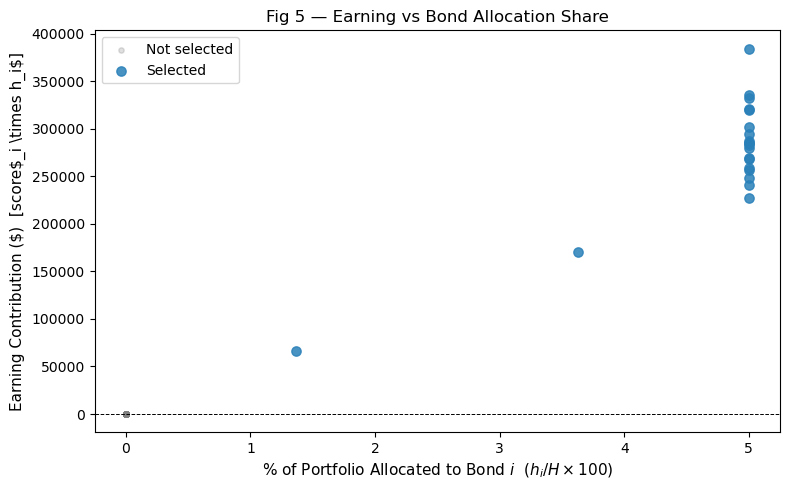

In [53]:
# =============================================================================
# 4E-1. FIG 5 — Earning Contribution vs Bond Allocation Share
# =============================================================================
# Each point is one bond.
# X : share of total portfolio budget allocated to bond i  (h_i / H * 100, in %)
# Y : earnings contribution of bond i  (score_i * h_i, in $)
# Selected bonds (h > $1) are highlighted in blue.

pct_alloc     = h_opt / H * 100          # portfolio weight of each bond (%)
earn_per_bond = score * h_opt            # earning contribution per bond ($)
sel           = h_opt > 1.0             # bonds with non-trivial allocation

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(pct_alloc[~sel], earn_per_bond[~sel],
           alpha=0.25, color="grey", s=15, label="Not selected")
ax.scatter(pct_alloc[sel],  earn_per_bond[sel],
           alpha=0.85, color="#2980b9", s=45, label="Selected")
ax.axhline(0, color="black", linewidth=0.7, linestyle="--")
ax.set_xlabel("% of Portfolio Allocated to Bond $i$  ($h_i / H \\times 100$)", fontsize=11)
ax.set_ylabel("Earning Contribution ($)  [score$_i \\times h_i$]",              fontsize=11)
ax.set_title("Fig 5 — Earning vs Bond Allocation Share", fontsize=12)
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# =============================================================================
# 4E-2. FIGS 6–8 — Optimal Earning (NEV) vs Each Constraint Bound
# =============================================================================

def _solve_nev(H_=H, rbc_bar_=RBC_bar, eps_D_=eps_D, r_save_=None, r_borrow_=None):
    if r_save_   is None: r_save_   = r_save
    if r_borrow_ is None: r_borrow_ = r_borrow

    m2 = gp.Model("sens"); m2.Params.LogToConsole = 0; m2.Params.OutputFlag = 0

    h2  = m2.addVars(N, lb=0.0)
    dp2 = m2.addVar(lb=0.0);  dn2 = m2.addVar(lb=0.0)
    tp2 = m2.addVars(N, lb=0.0); tm2 = m2.addVars(N, lb=0.0)
    B2  = m2.addVars(Q, lb=0.0); sn2 = m2.addVars(Q, lb=0.0)

    si2 = gp.quicksum(score[i] * h2[i]          for i in range(N))
    c1_ = gp.quicksum(theta[i] * h2[i]          for i in range(N))
    c3_ = alpha_w * (dp2 + dn2)
    tx_ = gp.quicksum(tau[i] * (tp2[i] + tm2[i]) for i in range(N))
    sv_ = gp.quicksum(r_save_   * dt_q * B2[q]   for q in range(Q - 1))
    bc_ = gp.quicksum(r_borrow_ * dt_q * sn2[q]  for q in range(Q))
    m2.setObjective(si2 + sv_ - gamma_w * (c1_ + c3_) - tx_ - bc_, GRB.MAXIMIZE)

    m2.addConstr(gp.quicksum(h2[i] for i in range(N)) == H_)
    m2.addConstr(gp.quicksum(spread[i] * h2[i] for i in range(N))
                 >= (rbc_bar_ * C_min - C_curr) / dt)
    m2.addConstr(gp.quicksum(durs[i] * h2[i] for i in range(N)) - D_FABN * H_
                 == dp2 - dn2)
    m2.addConstr(dp2 <= eps_D_ * H_); m2.addConstr(dn2 <= eps_D_ * H_)
    for i in range(N):
        m2.addConstr(h2[i] - h_curr[i] == tp2[i] - tm2[i])
    for iss, bidx in issuer_groups.items():
        m2.addConstr(gp.quicksum(h2[i] for i in bidx) <= delta * H_)
    for q in range(Q):
        cfa = gp.quicksum(aug_bond_cf[q, i] * h2[i] for i in range(N))
        cfl = float(qtr_fabn_cf[q])
        if q == 0: m2.addConstr(B2[q] - sn2[q] == cfa - cfl)
        else:      m2.addConstr(B2[q] - sn2[q] == (1.0 + r_save_ * dt_q) * B2[q-1] + cfa - cfl)
    m2.addConstr(
        gp.quicksum(df_q[q] * sn2[q] for q in range(Q)) <= phi_sf * PV_liability,
        name="pv_shortfall_limit"
    )

    m2.optimize()
    return m2.ObjVal if m2.Status == GRB.OPTIMAL else float("nan")

import warnings; warnings.filterwarnings("ignore")
n_pts = 20

H_range   = np.linspace(300e6, 700e6, n_pts)
rbc_range = np.linspace(1.0,   55.0,  n_pts)
eps_range = np.linspace(0.05,  1.5,   n_pts)

print("Sweeping constraints — 3×20 LP solves ...")
nev_H   = [_solve_nev(H_=v)       for v in H_range]
nev_rbc = [_solve_nev(rbc_bar_=v) for v in rbc_range]
nev_eps = [_solve_nev(eps_D_=v)   for v in eps_range]
print("Done.")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Optimal Earning (NEV) vs Constraint Bound — Parametric Sensitivity", fontsize=12)

_kw  = dict(marker="o", markersize=4, linewidth=1.8)
_kvl = dict(color="red", linewidth=1.0, linestyle="--")

ax = axes[0]
ax.plot(H_range / 1e6, nev_H, color="#2ecc71", **_kw)
ax.axvline(H / 1e6, **_kvl, label=f"Current H = ${H/1e6:.0f}M")
ax.set_xlabel("Budget  H  ($M)"); ax.set_ylabel("Optimal NEV ($)")
ax.set_title("Fig 6 — Constraint 1: Budget")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x/1e6:.2f}M"))
ax.legend(fontsize=8)

ax = axes[1]
ax.plot(rbc_range, nev_rbc, color="#3498db", **_kw)
ax.axvline(RBC_bar, **_kvl, label=f"Current RBC_bar = {RBC_bar}")
ax.set_xlabel("Min RBC Ratio  (RBC_bar)"); ax.set_ylabel("Optimal NEV ($)")
ax.set_title("Fig 7 — Constraint 2: Solvency (RBC)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x/1e6:.2f}M"))
ax.legend(fontsize=8)

ax = axes[2]
ax.plot(eps_range, nev_eps, color="#9b59b6", **_kw)
ax.axvline(eps_D, **_kvl, label=f"Current ε_D = {eps_D}")
ax.set_xlabel("Duration Tolerance  ε_D  (yrs)"); ax.set_ylabel("Optimal NEV ($)")
ax.set_title("Fig 8 — Constraint 3: Duration Alignment")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x/1e6:.2f}M"))
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [ ]:
# =============================================================================
# 4E-3. FIGS 10–11 — Issuer Concentration Constraint (2E)
# =============================================================================

# ── Fig 10: Current issuer allocations ───────────────────────────────────────
issuer_alloc = {}
for idx, cusip in enumerate(CUSIPS):
    issuer_alloc.setdefault(cusip[:6], 0.0)
    issuer_alloc[cusip[:6]] += h_opt[idx]

issuer_s = pd.Series(issuer_alloc).sort_values(ascending=False)
issuer_s = issuer_s[issuer_s > 1.0]

cap_line = delta * H
pct_s    = issuer_s / H * 100
cap_pct  = delta * 100

colors_10 = ["#e67e22" if v >= cap_line * 0.999 else "#3498db" for v in issuer_s.values]

fig, ax = plt.subplots(figsize=(max(10, len(issuer_s) * 0.38), 5))
ax.bar(range(len(issuer_s)), pct_s.values, color=colors_10, edgecolor="white", linewidth=0.4)
ax.axhline(cap_pct, color="red", linewidth=1.3, linestyle="--",
           label=f"Cap  δ = {cap_pct:.0f}%  (${cap_line/1e6:.1f}M per issuer)")
ax.set_xticks(range(len(issuer_s)))
ax.set_xticklabels(pct_s.index, rotation=90, fontsize=7)
ax.set_xlabel("Issuer  (first 6 CUSIP chars)", fontsize=10)
ax.set_ylabel("% of Total Budget  H", fontsize=10)
ax.set_title("Fig 10 — Issuer Concentration: Optimal Allocation vs Cap\n"
             "(orange = binding; blue = room below cap)", fontsize=11)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# ── Fig 11: NEV sensitivity to delta ─────────────────────────────────────────
delta_range = np.linspace(0.005, 0.20, 20)

def _solve_nev_delta(delta_):
    m3 = gp.Model("sens_delta"); m3.Params.LogToConsole = 0; m3.Params.OutputFlag = 0

    h3  = m3.addVars(N, lb=0.0)
    dp3 = m3.addVar(lb=0.0);  dn3 = m3.addVar(lb=0.0)
    tp3 = m3.addVars(N, lb=0.0); tm3 = m3.addVars(N, lb=0.0)
    B3  = m3.addVars(Q, lb=0.0); sn3 = m3.addVars(Q, lb=0.0)

    si3 = gp.quicksum(score[i] * h3[i]           for i in range(N))
    c1_ = gp.quicksum(theta[i] * h3[i]           for i in range(N))
    c3_ = alpha_w * (dp3 + dn3)
    tx_ = gp.quicksum(tau[i] * (tp3[i] + tm3[i])  for i in range(N))
    sv_ = gp.quicksum(r_save   * dt_q * B3[q]     for q in range(Q - 1))
    bc_ = gp.quicksum(r_borrow * dt_q * sn3[q]    for q in range(Q))
    m3.setObjective(si3 + sv_ - gamma_w * (c1_ + c3_) - tx_ - bc_, GRB.MAXIMIZE)

    m3.addConstr(gp.quicksum(h3[i] for i in range(N)) == H)
    m3.addConstr(gp.quicksum(spread[i] * h3[i] for i in range(N))
                 >= (RBC_bar * C_min - C_curr) / dt)
    m3.addConstr(gp.quicksum(durs[i] * h3[i] for i in range(N)) - D_FABN * H == dp3 - dn3)
    m3.addConstr(dp3 <= eps_D * H); m3.addConstr(dn3 <= eps_D * H)
    for i in range(N):
        m3.addConstr(h3[i] - h_curr[i] == tp3[i] - tm3[i])
    for iss, bidx in issuer_groups.items():
        m3.addConstr(gp.quicksum(h3[i] for i in bidx) <= delta_ * H)
    for q in range(Q):
        cfa = gp.quicksum(aug_bond_cf[q, i] * h3[i] for i in range(N))
        cfl = float(qtr_fabn_cf[q])
        if q == 0: m3.addConstr(B3[q] - sn3[q] == cfa - cfl)
        else:      m3.addConstr(B3[q] - sn3[q] == (1.0 + r_save * dt_q) * B3[q-1] + cfa - cfl)
    m3.addConstr(
        gp.quicksum(df_q[q] * sn3[q] for q in range(Q)) <= phi_sf * PV_liability,
        name="pv_shortfall_limit"
    )

    m3.optimize()
    return m3.ObjVal if m3.Status == GRB.OPTIMAL else float("nan")

import warnings; warnings.filterwarnings("ignore")
print("Sweeping issuer concentration cap — 20 LP solves ...")
nev_delta = [_solve_nev_delta(d) for d in delta_range]
print("Done.")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(delta_range * 100, nev_delta, "o-", color="#e74c3c", linewidth=1.8, markersize=4)
ax.axvline(delta * 100, color="red", linewidth=1.0, linestyle="--",
           label=f"Current δ = {delta:.0%}")
ax.set_xlabel("Max Issuer Allocation  δ  (% of H)", fontsize=11)
ax.set_ylabel("Optimal NEV ($)", fontsize=11)
ax.set_title("Fig 11 — Constraint 2E: NEV vs Issuer Concentration Cap (δ)", fontsize=12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x/1e6:.2f}M"))
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

In [ ]:
# =============================================================================
# 4E-4. FIGS 12–13 — NEV Sensitivity to Savings Rate (r_save) and Borrowing Rate (r_borrow)
# =============================================================================
# Sweeps each interest rate independently; all other parameters held at Section 2 values.
# Red dashed line = value used in the main run.

r_save_range   = np.linspace(0.00, 0.06, 20)   # 0 % → 6 %
r_borrow_range = np.linspace(0.01, 0.12, 20)   # 1 % → 12 %

print("Sweeping r_save and r_borrow — 2×20 LP solves ...")
nev_rsave   = [_solve_nev(r_save_=v)   for v in r_save_range]
nev_rborrow = [_solve_nev(r_borrow_=v) for v in r_borrow_range]
print("Done.")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Optimal NEV vs Interest Rates — Parametric Sensitivity", fontsize=12)

_kw  = dict(marker="o", markersize=4, linewidth=1.8)
_kvl = dict(color="red", linewidth=1.0, linestyle="--")

ax = axes[0]
ax.plot(r_save_range * 100, nev_rsave, color="#1abc9c", **_kw)
ax.axvline(r_save * 100, **_kvl, label=f"Current r_save = {r_save*100:.1f}%")
ax.set_xlabel("Savings Rate  r_save  (%)  — rate earned on surplus", fontsize=10)
ax.set_ylabel("Optimal NEV ($)")
ax.set_title("Fig 12 — NEV vs Surplus Savings Rate (r_save)", fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x/1e6:.2f}M"))
ax.legend(fontsize=9)

ax = axes[1]
ax.plot(r_borrow_range * 100, nev_rborrow, color="#e74c3c", **_kw)
ax.axvline(r_borrow * 100, **_kvl, label=f"Current r_borrow = {r_borrow*100:.1f}%")
ax.set_xlabel("Borrowing Rate  r_borrow  (%)  — rate paid on shortfalls", fontsize=10)
ax.set_ylabel("Optimal NEV ($)")
ax.set_title("Fig 13 — NEV vs CF Shortfall Borrowing Rate (r_borrow)", fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x/1e6:.2f}M"))
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()